# California Housing Price Prediction

## Machine Learning Model Comparison

### Models Used
- Linear Regression
- Ridge Regression
- Decision Tree Regression

**Objective:**
To compare the performance of three regression models using the California Housing dataset and evaluate them using RMSE and R² Score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)
df=housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.shape

(20640, 9)

In [4]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [8]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (16512, 8)
X_test shape : (4128, 8)
y_train shape: (16512,)
y_test shape : (4128,)


In [12]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [13]:
print(X_train_scaled[:5])

[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07750687
  -1.38217186  1.23269811]
 [-0.17148831  1.14200767  0.3490073   0.08662432 -0.48587717 -0.06883176
   0.5320839  -0.10855122]]


In [14]:
linear_model=LinearRegression()
linear_model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.85, 0.12,-0.29,...,-0.04,-0.9 ,-0.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.072
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[182.86,175.83,145. ,...,104.18, 36.96, 27.94]"


In [15]:
y_pred_linear=linear_model.predict(X_test_scaled)

In [16]:
rmse_linear = mean_squared_error(y_test, y_pred_linear) ** 0.5
r2_linear = r2_score(y_test, y_pred_linear)
print("Linear Regression Results")
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Results
RMSE: 0.7455813830127764
R² Score: 0.5757877060324508


In [17]:
ridge_model=Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled,y_train)
y_pred_ridge=ridge_model.predict(X_test_scaled)

rmse_ridge = mean_squared_error(y_test, y_pred_ridge) ** 0.5
r2_ridge = r2_score(y_test, y_pred_ridge)
print("Ridge Regression Results")
print("RMSE:", rmse_ridge)
print("R² Score:", r2_ridge)



Ridge Regression Results
RMSE: 0.7455789118982765
R² Score: 0.5757905180002314


In [18]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

rmse_tree = mean_squared_error(y_test, y_pred_tree) ** 0.5
r2_tree = r2_score(y_test, y_pred_tree)
print("Decision Tree Regression Results")
print("RMSE:", rmse_tree)
print("R² Score:", r2_tree)

Decision Tree Regression Results
RMSE: 0.7030332265476953
R² Score: 0.622823312540521


In [19]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree Regression"
    ],
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_tree
    ],
    "R2 Score": [
        r2_linear,
        r2_ridge,
        r2_tree
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745579,0.575791
2,Decision Tree Regression,0.703033,0.622823


In [20]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("Best Model:", best_model["Model"])
print("RMSE:", round(best_model["RMSE"], 4))
print("R² Score:", round(best_model["R2 Score"], 4))

Best Model: Decision Tree Regression
RMSE: 0.703
R² Score: 0.6228


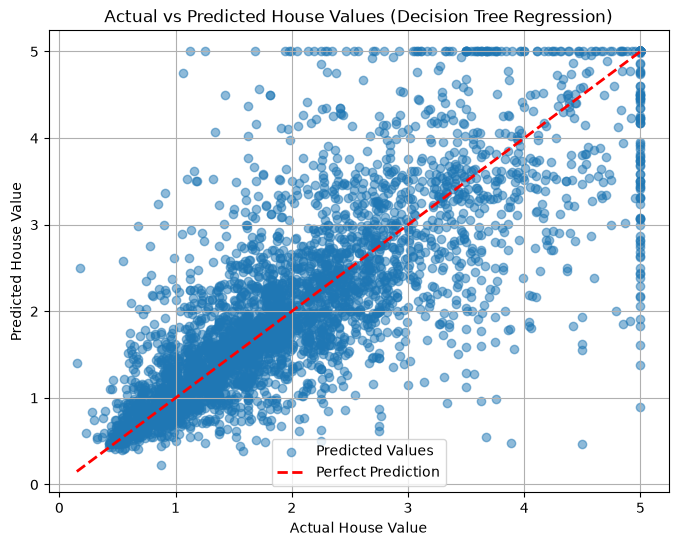

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_tree, alpha=0.5, label="Predicted Values")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values (Decision Tree Regression)")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: C:\Users\jkcho\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [23]:
import joblib

In [24]:
joblib.dump(tree_model, "best_model.pkl")

print("Model saved successfully!")

Model saved successfully!


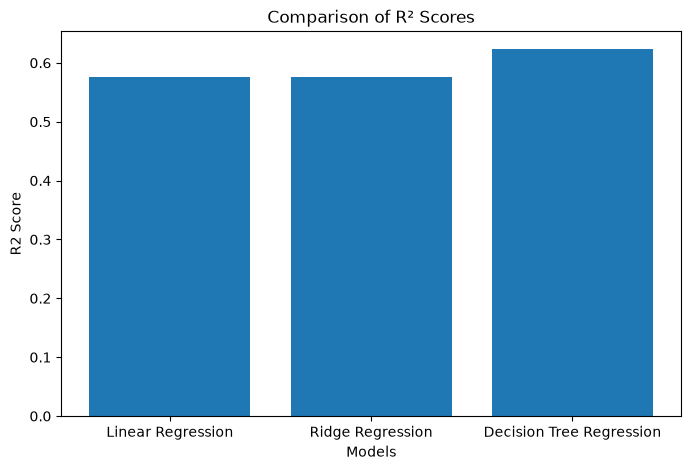

In [30]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Comparison of R² Scores")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()

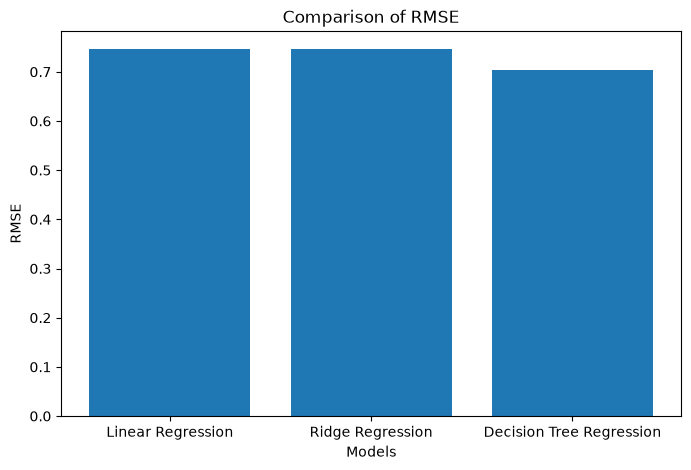

In [28]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Comparison of RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.show()

## Performance Insights

- Linear Regression served as the baseline model with an RMSE of 0.7456 and an R² Score of 0.5758.
- Ridge Regression produced almost identical results, indicating that regularization had minimal impact on this dataset.
- Decision Tree Regression achieved the best performance with the lowest RMSE (0.7030) and the highest R² Score (0.6228).
- Based on these results, Decision Tree Regression was selected as the best-performing model.